# 98 Degradation CE / ASR (EP FIGS. 19-27 analog)

$6\,\mathrm{M}$ KOH, $303\,\mathrm{K}$, isolation protects ORR.


## Governing equations

Default electrolyte $6\,\mathrm{M}$ KOH at $303\,\mathrm{K}$ unless noted.
Quantities use Jupyter MathJax with $\mathrm{}$ SI (siunitx is not available).
Patents: US12308414B2, EP4602674A1.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.degradation import Degradation
from plant_sim.components.base import integrate_component

deg = Degradation(P)
t, y = integrate_component(
    lambda t, y: deg.rhs(
        t,
        y,
        {
            "I_cell_A": 2.0,
            "eta_oer_V": 0.55,
            "r_carb_mol_s": 1e-7,
            "saturation": 0.25,
            "oer_isolated": 0.0 if t > 8e4 else 1.0,
        },
        {},
    ),
    deg.y0(),
    (0, 2e5),
    n_eval=200,
)
fade = [deg.outputs(float(ti), y[:, i], {}, {})["CE_fade"] for i, ti in enumerate(t)]

## CE / ASR aging trend (EP FIGS. 19–27 analog)

### What this plot illustrates

Engineering analog of patent CE and ASR trends over cycling—not a digitized figure reconstruction.

### Governing equations

$\mathrm{CE}(N)=\mathrm{CE_0}-k_\mathrm{CE} N$, $\mathrm{ASR}(N)=\mathrm{ASR_0}(1+k_\mathrm{ASR} N)$ as a compact aging ODE forcing.


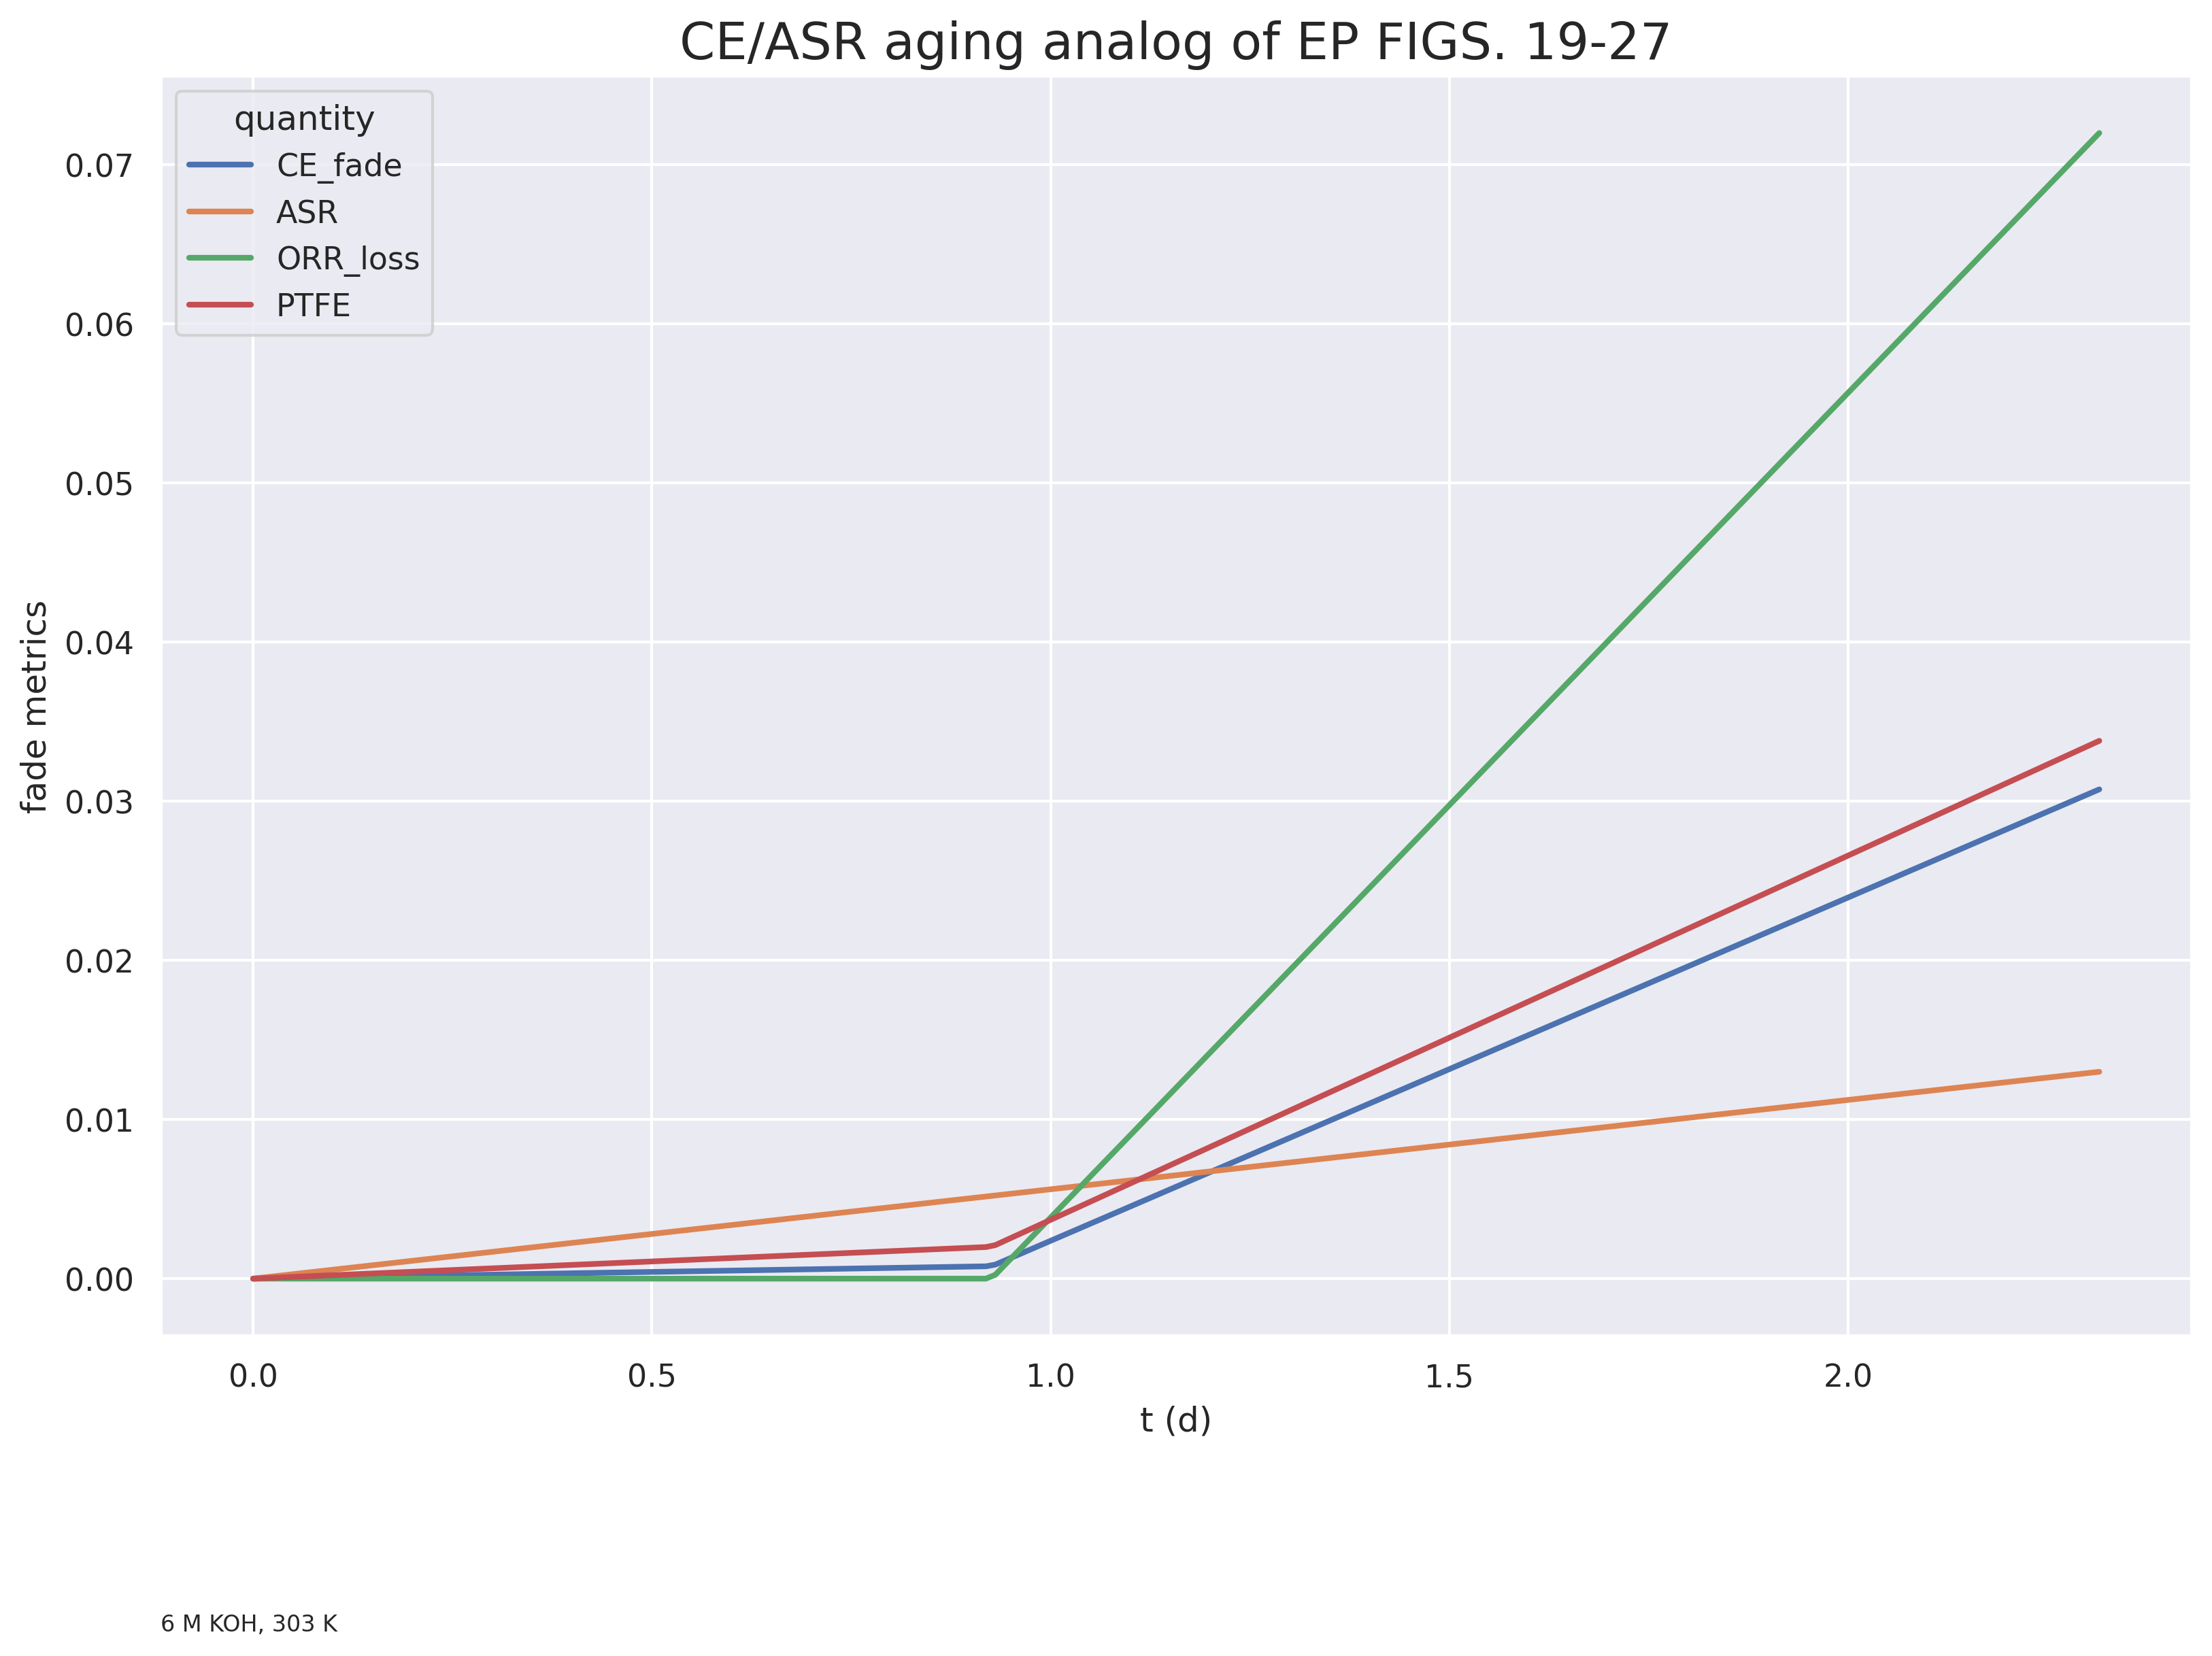

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 86400),
        "CE_fade": (fade),
        "ASR": (y[1]),
        "ORR_loss": (y[2]),
        "PTFE": (y[3]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (d)")
ax.set_ylabel("fade metrics")
ax.set_title("CE/ASR aging analog of EP FIGS. 19-27")
ax.text(0.0, -0.22, "6 M KOH, 303 K", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Verification against patents / SSS002

In [5]:
print("finite trajectories and patent-window parameters: see printed checks above")

finite trajectories and patent-window parameters: see printed checks above
